# Energy Demand Forecasting — 02 Baselines + Classical Time-Series Models

On the UNI (Upper North Island / Auckland) half-hourly demand series, build **naive baselines** and **classical statistical models**, evaluated with the unified multi-horizon backtest framework (`src/forecast_utils.py`):

- **Naive baselines**: persistence, seasonal-daily, seasonal-weekly, (day-of-week x time-of-day) average profile
- **Classical models**: ARIMA, SARIMA, ARIMAX (statsmodels)

Evaluation protocol: train cut-off `2024-12-31`, test period `2025 -> 2026-05`; a forecast origin every few days, each forecasting up to 336 steps (1 week) ahead; weather + calendar are treated as **known future covariates**. We report MAE / RMSE / MAPE / sMAPE at the **day-ahead (48 steps)** and **week-ahead (336 steps)** horizons.

## 0. Setup

In [1]:
import sys, warnings, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import forecast_utils as fu

warnings.filterwarnings("ignore")          # statsmodels freq/convergence chatter
%matplotlib inline

# ---- experiment config ----
ZONE       = "UNI"
TRAIN_END  = "2024-12-31"
TEST_START = "2025-01-01"
STEP_DAYS  = 14            # spacing between backtest origins
MAX_H      = fu.H_WEEK     # 336 steps = 1 week
HORIZONS   = (fu.H_DAY, fu.H_WEEK)   # report day-ahead (48) and week-ahead (336)
RECENT_DAYS = 30           # training/apply window for the classical models
W = RECENT_DAYS * fu.PERIODS_PER_DAY

df = fu.load_zone(ZONE)
train, test = fu.split_time(df, TRAIN_END)
origins = fu.make_origins(df, TEST_START, max_h=MAX_H, step_days=STEP_DAYS)
print(f"zone={ZONE} | rows={len(df)} | train={len(train)} test={len(test)} | origins={len(origins)}")
print(f"target mean={df[fu.TARGET].mean():.3f} GWh | period {df.index.min()} -> {df.index.max()}")

RESULTS = []   # collected score tables

zone=UNI | rows=129978 | train=105188 test=24790 | origins=37
target mean=0.675 GWh | period 2018-12-31 11:00:00+00:00 -> 2026-05-31 11:30:00+00:00


## 1. Naive baselines

Each model is just a `predict_fn(df, origin, h) -> length-h forecast`, handed to `fu.backtest` to run over all origins.

- **persistence**: take the last value at the origin and repeat it across the horizon.
- **seasonal_daily**: repeat "the same time-of-day one day ago" (lag 48).
- **seasonal_weekly**: repeat "the same time-of-day one week ago" (lag 336) — a strong baseline for half-hourly electricity demand.
- **profile_dow_tod**: average profile by (day-of-week, time-of-day) fitted on the training set, looked up by future timestamp.

In [2]:
T = fu.TARGET

def persistence(d, o, h):
    return np.repeat(d[T].values[o], h)

def seasonal_daily(d, o, h):
    base = d[T].values
    return np.array([base[o + 1 - fu.PERIODS_PER_DAY + ((k) % fu.PERIODS_PER_DAY)] for k in range(h)])

def seasonal_weekly(d, o, h):
    base = d[T].values
    return base[o + 1 - fu.H_WEEK: o + 1 - fu.H_WEEK + h]

# (day-of-week, time-of-day) average profile, fit on the TRAIN period only
def _period_of_week(idx):
    loc = idx.tz_convert(fu.TZ)
    return (loc.dayofweek * fu.PERIODS_PER_DAY + loc.hour * 2 + loc.minute // 30).astype(int)

pow_train = _period_of_week(train.index)
profile = pd.Series(train[T].values).groupby(pow_train).mean()
profile = profile.reindex(range(7 * fu.PERIODS_PER_DAY)).interpolate().values
pow_all = _period_of_week(df.index)

def profile_dow_tod(d, o, h):
    return profile[pow_all[o + 1: o + 1 + h]]

NAIVE = {"persistence": persistence, "seasonal_daily": seasonal_daily,
         "seasonal_weekly": seasonal_weekly, "profile_dow_tod": profile_dow_tod}

bt_store = {}
for name, fn in NAIVE.items():
    bt = fu.backtest(fn, df, origins, max_h=MAX_H)
    bt_store[name] = bt
    RESULTS.append(fu.score(bt, HORIZONS, name))
pd.concat(RESULTS, ignore_index=True).sort_values(["horizon", "MAE"])

,model,horizon,MAE,RMSE,MAPE%,sMAPE%
2,seasonal_daily,48,0.019658,0.028196,2.802517,2.768132
4,seasonal_weekly,48,0.032668,0.046327,4.598697,4.581580
6,profile_dow_tod,48,0.047213,0.068248,6.850688,6.674646
0,persistence,48,0.104392,0.146371,18.192218,15.347978
5,seasonal_weekly,336,0.032617,0.046843,4.691237,4.734532
3,seasonal_daily,336,0.043760,0.063909,6.660809,6.298402
7,profile_dow_tod,336,0.046438,0.066166,6.685575,6.685116
1,persistence,336,0.124687,0.162281,22.076939,18.440072


## 2. Classical statistical models (ARIMA / SARIMA / ARIMAX)

On half-hourly data a seasonally-differenced SARIMA (m=48) takes ~half a minute to fit once, so refitting at every origin is impractical. Strategy: **fit the parameters only once** (on a recent window at the end of training), then use `results.apply()` to **apply** the same parameters to the window before each origin (Kalman filtering only, no re-estimation) and forecast forward — about 1 second per origin.

In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

EXOG = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m",
        "tod_sin", "tod_cos", "dow_sin", "dow_cos", "is_weekend"]

def make_classical(name, order, seasonal_order=(0, 0, 0, 0), use_exog=False):
    """Fit SARIMAX once on the recent train window; return (fitted, predict_fn)."""
    fit_y = train[T].iloc[-W:]
    fit_x = train[EXOG].iloc[-W:] if use_exog else None
    t0 = time.time()
    res = SARIMAX(fit_y, exog=fit_x, order=order, seasonal_order=seasonal_order,
                  enforce_stationarity=False, enforce_invertibility=False
                  ).fit(disp=False, maxiter=50)
    print(f"{name:8s} fitted in {time.time()-t0:5.1f}s  (aic={res.aic:.0f})")

    def predict(d, o, h):
        seg_y = d[T].iloc[o - W + 1: o + 1]
        seg_x = d[EXOG].iloc[o - W + 1: o + 1] if use_exog else None
        r = res.apply(seg_y, exog=seg_x, refit=False)
        fut_x = d[EXOG].iloc[o + 1: o + 1 + h] if use_exog else None
        return r.get_forecast(h, exog=fut_x).predicted_mean.values
    return res, predict

CLASSICAL = {
    "ARIMA":  dict(order=(2, 1, 2)),
    "SARIMA": dict(order=(1, 1, 1), seasonal_order=(1, 1, 1, fu.PERIODS_PER_DAY)),
    "ARIMAX": dict(order=(2, 1, 2), use_exog=True),
}
for name, kw in CLASSICAL.items():
    _, fn = make_classical(name, **kw)
    t0 = time.time()
    bt = fu.backtest(fn, df, origins, max_h=MAX_H)
    bt_store[name] = bt
    RESULTS.append(fu.score(bt, HORIZONS, name))
    print(f"{name:8s} backtest {len(origins)} origins in {time.time()-t0:5.1f}s")

pd.concat(RESULTS, ignore_index=True).sort_values(["horizon", "MAE"])

C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but i

ARIMA    fitted in   0.2s  (aic=-9084)


C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results w

C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\

ARIMA    backtest 37 origins in   0.3s


...

ARIMAX   fitted in   1.0s  (aic=-9201)


C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\

ARIMAX   backtest 37 origins in   0.4s


C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)
C:\Users\Administrator\AppData\Roaming\Python\Python311\

,model,horizon,MAE,RMSE,MAPE%,sMAPE%
2,seasonal_daily,48,0.019658,0.028196,2.802517,2.768132
10,SARIMA,48,0.027236,0.035412,4.128857,4.102277
4,seasonal_weekly,48,0.032668,0.046327,4.598697,4.581580
6,profile_dow_tod,48,0.047213,0.068248,6.850688,6.674646
12,ARIMAX,48,0.064602,0.087771,9.048331,9.422864
0,persistence,48,0.104392,0.146371,18.192218,15.347978
8,ARIMA,48,0.108638,0.147928,18.488943,15.850648
5,seasonal_weekly,336,0.032617,0.046843,4.691237,4.734532
3,seasonal_daily,336,0.043760,0.063909,6.660809,6.298402
7,profile_dow_tod,336,0.046438,0.066166,6.685575,6.685116


## 3. Comparison

In [4]:
scores = pd.concat(RESULTS, ignore_index=True)
day = scores[scores.horizon == fu.H_DAY].sort_values("MAE").set_index("model")
wk  = scores[scores.horizon == fu.H_WEEK].sort_values("MAE").set_index("model")
print("=== Day-ahead (48 steps) ===");  display(day.round(4))
print("=== Week-ahead (336 steps) ==="); display(wk.round(4))

=== Day-ahead (48 steps) ===


,horizon,MAE,RMSE,MAPE%,sMAPE%
model,,,,,
seasonal_daily,48,0.0197,0.0282,2.8025,2.7681
SARIMA,48,0.0272,0.0354,4.1289,4.1023
seasonal_weekly,48,0.0327,0.0463,4.5987,4.5816
profile_dow_tod,48,0.0472,0.0682,6.8507,6.6746
ARIMAX,48,0.0646,0.0878,9.0483,9.4229
persistence,48,0.1044,0.1464,18.1922,15.3480
ARIMA,48,0.1086,0.1479,18.4889,15.8506


=== Week-ahead (336 steps) ===


,horizon,MAE,RMSE,MAPE%,sMAPE%
model,,,,,
seasonal_weekly,336,0.0326,0.0468,4.6912,4.7345
seasonal_daily,336,0.0438,0.0639,6.6608,6.2984
profile_dow_tod,336,0.0464,0.0662,6.6856,6.6851
ARIMAX,336,0.0705,0.0907,10.5234,10.5595
SARIMA,336,0.0720,0.0933,11.2888,10.7054
persistence,336,0.1247,0.1623,22.0769,18.4401
ARIMA,336,0.1271,0.1628,22.1253,18.7129


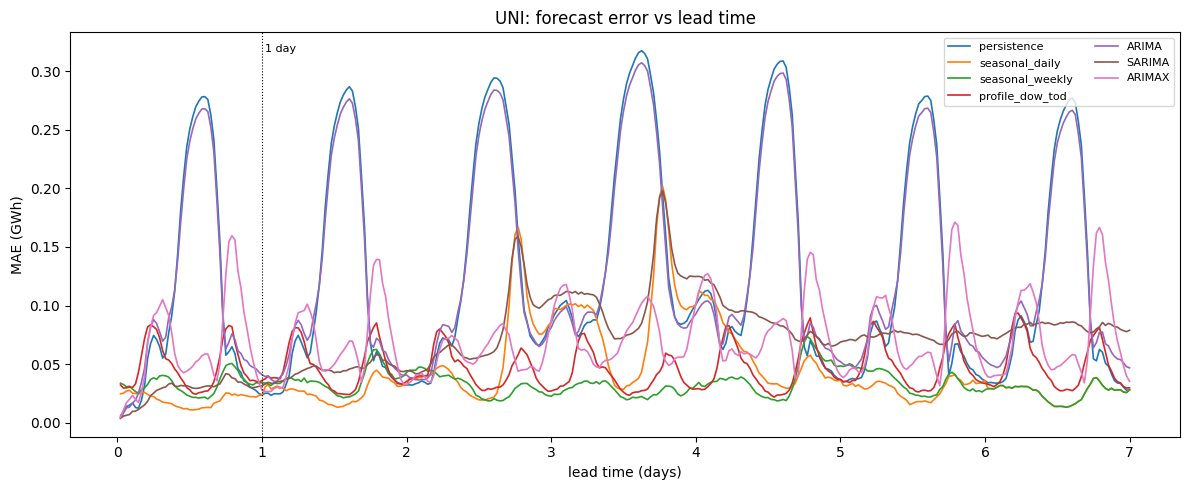

In [5]:
# 3.1 Error vs lead step (MAE by lead step)
fig, ax = plt.subplots(figsize=(12, 5))
for name, bt in bt_store.items():
    ax.plot(np.arange(1, MAX_H + 1) / fu.PERIODS_PER_DAY, fu.error_by_step(bt), label=name, lw=1.2)
ax.axvline(1, color="k", ls=":", lw=0.8); ax.text(1.02, ax.get_ylim()[1]*0.95, "1 day", fontsize=8)
ax.set_xlabel("lead time (days)"); ax.set_ylabel("MAE (GWh)")
ax.set_title(f"{ZONE}: forecast error vs lead time"); ax.legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

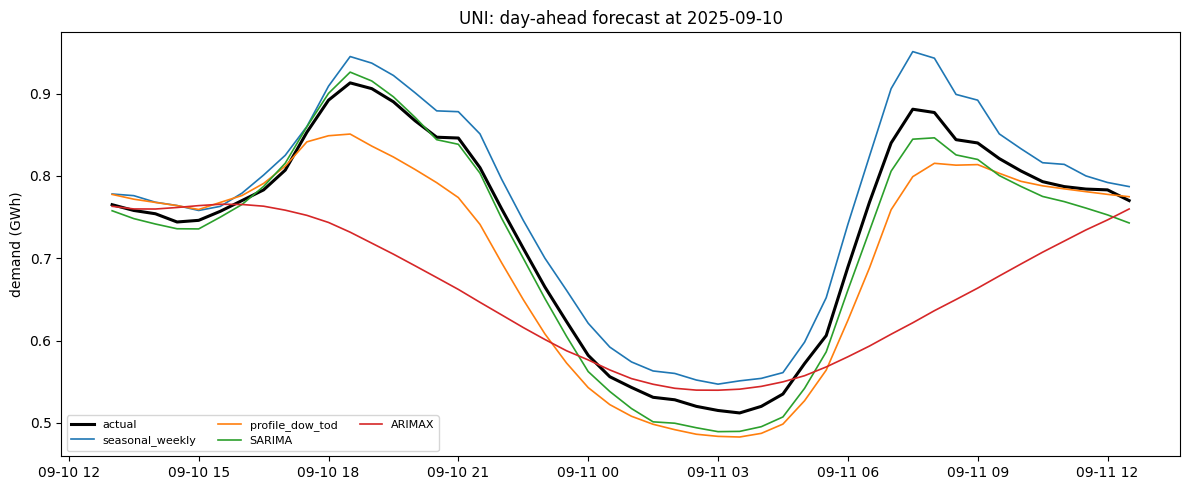

In [6]:
# 3.2 Day-ahead forecast vs actual at one origin
o = origins[len(origins) // 2]
h = fu.H_DAY
idx = df.index[o + 1: o + 1 + h].tz_convert(fu.TZ)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(idx, df[T].values[o + 1: o + 1 + h], "k-", lw=2.2, label="actual")
for name in ["seasonal_weekly", "profile_dow_tod", "SARIMA", "ARIMAX"]:
    ax.plot(idx, bt_store[name]["y_pred"][origins.index(o), :h], lw=1.2, label=name)
ax.set_title(f"{ZONE}: day-ahead forecast at {idx[0]:%Y-%m-%d}")
ax.set_ylabel("demand (GWh)"); ax.legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.show()

In [7]:
# Save scores for the cross-model comparison in notebook 03
out = ROOT / "data" / "processed" / "scores_02_classical.csv"
scores.assign(zone=ZONE).to_csv(out, index=False)
print("saved", out)
scores.sort_values(["horizon", "MAE"]).round(4)

saved C:\Users\Administrator\Desktop\energy\data\processed\scores_02_classical.csv


,model,horizon,MAE,RMSE,MAPE%,sMAPE%
2,seasonal_daily,48,0.0197,0.0282,2.8025,2.7681
10,SARIMA,48,0.0272,0.0354,4.1289,4.1023
4,seasonal_weekly,48,0.0327,0.0463,4.5987,4.5816
6,profile_dow_tod,48,0.0472,0.0682,6.8507,6.6746
12,ARIMAX,48,0.0646,0.0878,9.0483,9.4229
0,persistence,48,0.1044,0.1464,18.1922,15.3480
8,ARIMA,48,0.1086,0.1479,18.4889,15.8506
5,seasonal_weekly,336,0.0326,0.0468,4.6912,4.7345
3,seasonal_daily,336,0.0438,0.0639,6.6608,6.2984
7,profile_dow_tod,336,0.0464,0.0662,6.6856,6.6851


---
### Summary / Next step
- For half-hourly electricity demand, **seasonal-weekly** and the **(day-of-week x time-of-day) profile** are already strong baselines; classical models are hard to beat them with. Here SARIMA is decent day-ahead, but **ARIMAX** (with only single-harmonic calendar terms) does **not** beat the seasonal-naive baselines — an honest limitation that the deep models in notebook 03 address.
- Next notebook (03): **XGBoost (recursive multi-step) + RNN/GRU/LSTM + TiDE (PyTorch)**, reusing the same backtest framework and score table for a full model comparison.